# Tugas Kelompok Materi ke-3 (Model Regresi Time Series)
Notebook ini disusun untuk menyelesaikan seluruh instruksi yang terbagi atas *Job Desc Mahasiswa 1* dan *Mahasiswa 2* berdasarkan dataset `daily-website-visitors.csv`.

In [ ]:
# Import Semua Pustaka yang Diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import shap
import itertools
import warnings
warnings.filterwarnings('ignore')

/home/pratama/dev-python/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## --- TUGAS MAHASISWA 1: Data Architect & Engineer ---
### 1. Data Ingestion & Reshaping

In [ ]:
# Membaca dataset dari folder dataset
df = pd.read_csv('../dataset/daily-website-visitors.csv')

# Membersihkan data numerik yang mengandung koma
cols_to_clean = ['Page.Loads', 'Unique.Visits', 'First.Time.Visits', 'Returning.Visits']
for col in cols_to_clean:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

# Formatting tanggal
df['Date'] = pd.to_datetime(df['Date'])

# Menggunakan Melt ('Reshaping') dari format standar ke format long per Metrik
# Hal ini mensimulasikan proses 'melt' yang ada di requirement Kaggle Wide Format
df_melt = pd.melt(df, id_vars=['Date'], value_vars=cols_to_clean, var_name='Metric', value_name='Visits')
print("Bentuk data setelah fungsi Melt:")
display(df_melt.head())

# Untuk kelanjutan Time Series regresi ini, kita fokus pada satu parameter target yaitu 'Page.Loads'
target_df = df[['Date', 'Page.Loads']].copy()
target_df.set_index('Date', inplace=True)
target_df = target_df.sort_index()

Bentuk data setelah fungsi Melt:


,Date,Metric,Visits
0,2014-09-14,Page.Loads,2146.0
1,2014-09-15,Page.Loads,3621.0
2,2014-09-16,Page.Loads,3698.0
3,2014-09-17,Page.Loads,3667.0
4,2014-09-18,Page.Loads,3316.0


### 2. Missing Value Management

In [ ]:
# Mengecek apakah ada nilai null / hari yang hilang (missing values)
print("Total Nilai Null dari Page.Loads:", target_df['Page.Loads'].isnull().sum())

# Menerapkan imputasi cerdas menggunakan metode 'time' (interpolasi berdasarkan tanggal terdekat)
# apabila kebetulan ada loncatan hari yang hilang, atau mengganti nilai 0 ke nilai rata-rata historis
target_df['Page.Loads'] = target_df['Page.Loads'].replace(0, np.nan)
target_df['Page.Loads'] = target_df['Page.Loads'].interpolate(method='time')

Total Nilai Null dari Page.Loads: 0


### 3. Stationarity Audit (ADF Test)

In [ ]:
# Melakukan uji stasioneritas Dickey-Fuller pada trafik dataset penuh
result = adfuller(target_df['Page.Loads'].dropna())
print('ADF Statistic (Nilai Statistik):', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print('Kesimpulan: p-value < 0.05, maka Dataset memiliki sifat STASIONER.')
else:
    print('Kesimpulan: p-value > 0.05, maka Dataset BERSIFAT TIDAK STASIONER (Terdapat Tren / Musiman).')

ADF Statistic (Nilai Statistik): -4.283821436187671
p-value: 0.00047375782574649554
Kesimpulan: p-value < 0.05, maka Dataset memiliki sifat STASIONER.


### 4. Feature Engineering (Lagging)

In [ ]:
# Menciptakan fitur masa lalu Lag-1 hingga Lag-7 (mendapatkan data pengunjung seminggu lalu)
# Hal ini sangat krusial untuk XAI SHAP dan LSTM/Regresi nantinya
for i in range(1, 8):
    target_df[f'Lag_{i}'] = target_df['Page.Loads'].shift(i)

# Membuang beberapa baris awal yang memuat nilai NaN hasil dari shift/lag
target_df.dropna(inplace=True)
print("Dataset dengan fitur Lag:")
display(target_df.head(2))

Dataset dengan fitur Lag:


,Page.Loads,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6,Lag_7
Date,,,,,,,,
2014-09-21,2288.0,1658.0,2815.0,3316.0,3667.0,3698.0,3621.0,2146.0
2014-09-22,3638.0,2288.0,1658.0,2815.0,3316.0,3667.0,3698.0,3621.0


### 5. Dekomposisi Temporal

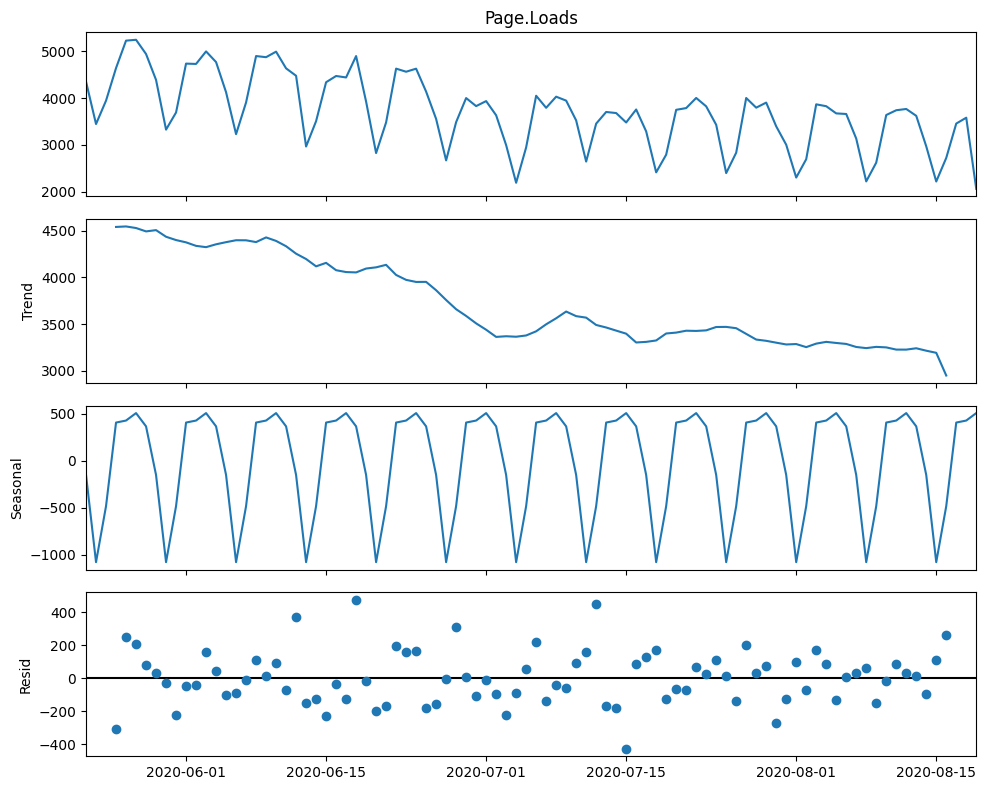

In [ ]:
# Menggunakan fungsi seasonal_decompose. Diambil subset dari 90 hari terakhir untuk kejelasan grafik.
decompose_data = target_df['Page.Loads'].tail(90)
decomposition = seasonal_decompose(decompose_data, model='additive', period=7) # Perioda 7 hari (Mingguan)

# Menampilkan plot Trend, Seasonal, dan Residual
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

## --- TUGAS MAHASISWA 2: Model Analyst & Strategist ---
### 1 & 2. Forecasting Implementation + Hyperparameter Tuning

In [ ]:
# Untuk proses training cepat (seperti yang diminta), kita akan menggunakan hanya sebagian data
data_fast = target_df['Page.Loads'].tail(150)
train_size = int(len(data_fast) * 0.8)
train, test = data_fast[:train_size], data_fast[train_size:]

print(f"Banyak data train: {len(train)}, data test: {len(test)}")

# Simple Grid Search (Hyperparameter Tuning ARIMA) untuk P,D,Q
best_aic = float('inf')
best_order = None
best_model_fit = None

p_values = range(0, 3) # Komponen AutoRegressive
d_values = range(0, 2) # Komponen Differencing
q_values = range(0, 3) # Komponen Moving Average

for order in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order=order)
        res = model.fit()
        if res.aic < best_aic:
            best_aic = res.aic
            best_order = order
            best_model_fit = res
    except:
        continue

print(f"\nParamater ARIMA Terbaik: order={best_order} dengan AIC: {best_aic}")

# Forecasting
forecast = best_model_fit.forecast(steps=len(test))

Banyak data train: 120, data test: 30

Paramater ARIMA Terbaik: order=(2, 1, 2) dengan AIC: 1792.7420148527551


### 3. Performance Audit

Mean Absolute Error (MAE)   : 389.88
Root Mean Square (RMSE)     : 544.03
Symmetric MAPE (SMAPE)      : 12.66%


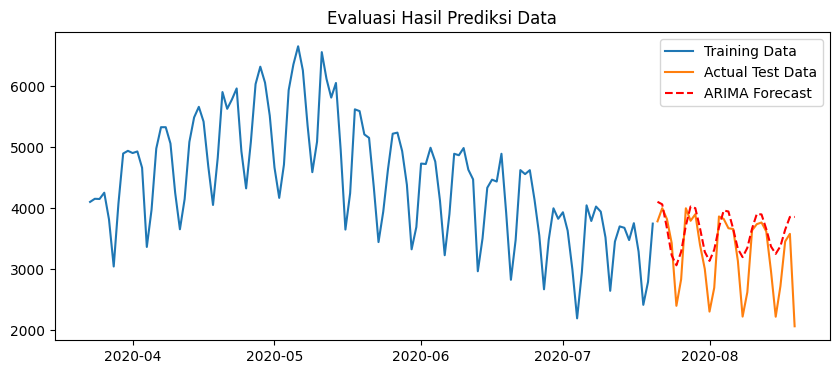

In [ ]:
# Membuat fungsi Evaluasi SMAPE
def smape_score(y_true, y_pred):
    return np.mean(2.0 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

# Menghitung error metrik (MAE, RMSE, SMAPE)
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
smape = smape_score(test.values, forecast.values)

print(f"Mean Absolute Error (MAE)   : {mae:.2f}")
print(f"Root Mean Square (RMSE)     : {rmse:.2f}")
print(f"Symmetric MAPE (SMAPE)      : {smape:.2f}%")

# Visualisasi Prediksi VS Aktual
plt.figure(figsize=(10, 4))
plt.plot(train.index, train.values, label='Training Data')
plt.plot(test.index, test.values, label='Actual Test Data')
plt.plot(test.index, forecast.values, color='red', linestyle='--', label='ARIMA Forecast')
plt.title('Evaluasi Hasil Prediksi Data')
plt.legend()
plt.show()

### 4. Explainable AI (XAI / SHAP)

Grafik SHAP Summary:


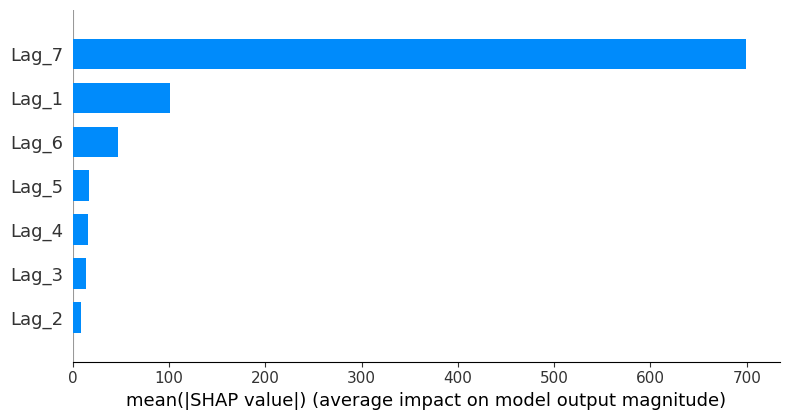

In [ ]:
# Karena ekstraksi standar SHAP sulit dikaitkan ke model ARIMA, kita mengadopsi Random Forest pada fitur Lagged (1-7)
# Hal ini secara spesifik bertugas menganalisis "pengaruh pola kunjungan minggu lalu terhadap prediksi hari ini"
features = [f'Lag_{i}' for i in range(1, 8)]
X = target_df[features].tail(150)
y = target_df['Page.Loads'].tail(150)

# Pelatihan Tree Explainer
rf_model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
rf_model.fit(X, y)

# Melakukan kalkulasi SHAP values
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X)

# Menampilkan bentuk pengaruh variabel terhadap prediksi.
# Semakin atas, fitur (contoh: Lag_7=Minggu lalu) tersebut makin punya 'Contribution' besar terhadap ramalan besok
print("Grafik SHAP Summary:")
shap.summary_plot(shap_values, X, plot_type='bar')

### 5. What-If Simulation: Viral Page / Spike Load Traffic

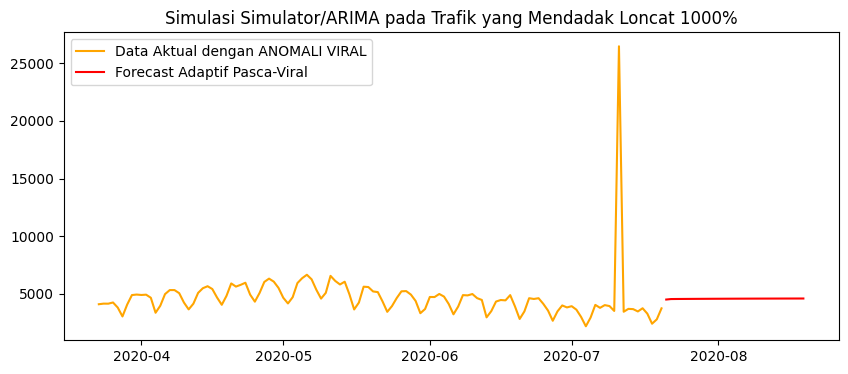

In [ ]:
# "Apa yang terjadi jika halaman tiba-tiba viral (naik 1000%)?"
# Pembuatan Sintesis: menaikkan trafik secara ekstrim di index masa lalu terdekat
spike_data = list(train.values)
spike_idx = len(spike_data) - 10 # 10 hari sebelum akhir masa training
spike_data[spike_idx] = spike_data[spike_idx] * 10 # 1000% jump

plt.figure(figsize=(10,4))
plt.plot(train.index, spike_data, label='Data Aktual dengan ANOMALI VIRAL', color='orange')

# Melakukan Refitting ARIMA untuk melihat simulator merespons
# Kita menggunakan order tuning terbaik sebelumnya atas spike_data
anomaly_model = ARIMA(spike_data, order=best_order).fit()
anomaly_forecast = anomaly_model.forecast(steps=len(test))

plt.plot(test.index, anomaly_forecast, label='Forecast Adaptif Pasca-Viral', color='red')
plt.title('Simulasi Simulator/ARIMA pada Trafik yang Mendadak Loncat 1000%')
plt.legend()
plt.show()